# Image Classification of Cats and Dogs 
## Using Support Vector Machine (SVM)

In [1]:
# Import libraries
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
# Dataset folder path
dataset_path = r"C:\Users\admin\Desktop\SkillCraft Internship\TASK - 3\Dogs vs Cats Dataset\train"

In [3]:
# Image size
IMG_SIZE = 32

In [4]:
# Lists to store data
X = []
y = []


In [5]:
# Load images
for category in ["train_cats", "train_dogs"]:
    folder_path = os.path.join(dataset_path, category)
    label = 0 if category == "train_cats" else 1    
    for image_name in os.listdir(folder_path)[:500]:
        image_path = os.path.join(folder_path, image_name)
        try:
            # Read image
            img = cv2.imread(image_path)
            # Resize image
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            # Flatten image into 1D array
            img = img.flatten()
            # Store data
            X.append(img)
            y.append(label)

        except:
            pass

In [6]:
# Convert to numpy arrays
X = np.array(X)
y = np.array(y)


In [7]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Create SVM model
model = SVC(kernel='linear')

# Train model
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
# Predict
y_pred = model.predict(X_test)

In [10]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.525


In [17]:
# Test with a new image
test_image = r"C:\Users\admin\Desktop\SkillCraft Internship\TASK - 3\cat.jpg"

img = cv2.imread(test_image)

img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

img_flat = img_resized.flatten().reshape(1, -1)

prediction = model.predict(img_flat)

if prediction[0] == 0:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

Prediction: Cat


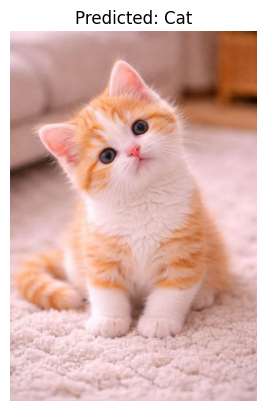

In [18]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.title("Predicted: Cat" if prediction[0] == 0 else "Predicted: Dog")

plt.axis("off")

plt.show()